Working with Andy to write neural network to predict location from RBCL 2/24/2023

Load Packages

In [1]:
import pandas as pd
import numpy as np

Import dataset and create features (X) and targets (y)

In [2]:
#data imports
df_si = pd.read_csv("spec_RBCL_16s.csv", low_memory=False)
df_ffar = pd.read_csv("FFARspec.csv", low_memory=False)

#isolate the columns that startwith RBCL
rbcl_cols = [col for col in df_si if col.startswith('RBCL')]

#specify which columns we want to keep
my_cols = ['UniqueID', 'Family', 'Genus', 'Site', 'Lat', 'Long'] + rbcl_cols
df_si = df_si.reindex(columns=my_cols)

#get rid of nas
df_si1 = df_si.dropna(subset=[i for i in rbcl_cols], how='all')
df_si1 = df_si1.fillna(0)

#repeat for ffar bees -- will need to repeat for updated data from oregon and si before joining but 
#steps will be the same 

rbcl_cols2 = [col for col in df_ffar if col.startswith('RBCL')]
my_cols2 = ['UniqueID', 'Family', 'Genus', 'GenSp', 'Site', 'Lat', 'Long'] + rbcl_cols2
df_ffar = df_ffar.reindex(columns=my_cols2)
df_ffar1 = df_ffar.dropna(subset=[i for i in rbcl_cols2], how='all')
df_ffar1 = df_ffar1.fillna(0)

#join the datasets
df_all = pd.concat([df_si1,df_ffar1], axis=0, ignore_index=True)

#fix induced nas
df_all = df_all.fillna(0)

#store columns that start with rbcl
rbcl_cols = [col for col in df_all if col.startswith('RBCL')]

#keep the feature columns and target columns
my_cols = ['Lat', 'Long'] + rbcl_cols
df_all = df_all[my_cols]
df_all = df_all.reindex(columns=my_cols)

#create the features
X = df_all.drop('Lat',axis=1)
X = X.drop('Long',axis=1)

#create the targets
lat = np.array(df_all['Lat'])
long = np.array(df_all['Long'])
y = np.column_stack((lat, long)) 

Tutorial: https://machinelearningmastery.com/regression-tutorial-keras-deep-learning-library-python/

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.losses import MeanSquaredError

In [53]:
## what we want:
# 2-3 layers
# first layer 128, second layer 128, then 24, then final output is 2

model = Sequential()
model.add(Dense(128, input_shape=(182,), kernel_initializer='he_normal', activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(24,  activation='relu'))
model.add(Dense(2, activation='linear'))
# Compile model
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])

In [54]:
#train test split (80% training)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=123)

#train test split again to get test and validation (10% test 10% validation)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=123)


In [55]:
history = model.fit(X_train,
                    y_train,
                    epochs=50,
                    validation_data=(X_val, y_val))

Epoch 1/50
35/35 [==============================] - 2s 14ms/step - loss: 7667.0034 - accuracy: 1.0000 - val_loss: 6961.9336 - val_accuracy: 1.0000
Epoch 2/50
35/35 [==============================] - 0s 5ms/step - loss: 4566.5474 - accuracy: 1.0000 - val_loss: 876.7551 - val_accuracy: 1.0000
Epoch 3/50
35/35 [==============================] - 0s 6ms/step - loss: 170.9819 - accuracy: 1.0000 - val_loss: 33.0438 - val_accuracy: 1.0000
Epoch 4/50
35/35 [==============================] - 0s 9ms/step - loss: 20.4929 - accuracy: 1.0000 - val_loss: 6.6154 - val_accuracy: 1.0000
Epoch 5/50
35/35 [==============================] - 0s 6ms/step - loss: 6.6589 - accuracy: 1.0000 - val_loss: 3.1130 - val_accuracy: 1.0000
Epoch 6/50
35/35 [==============================] - 0s 6ms/step - loss: 3.8373 - accuracy: 1.0000 - val_loss: 2.0990 - val_accuracy: 1.0000
Epoch 7/50
35/35 [==============================] - 0s 5ms/step - loss: 2.5759 - accuracy: 1.0000 - val_loss: 1.6393 - val_accuracy: 1.0000
Epoc

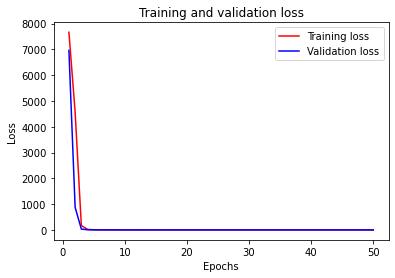

In [56]:
import matplotlib.pyplot as plt
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

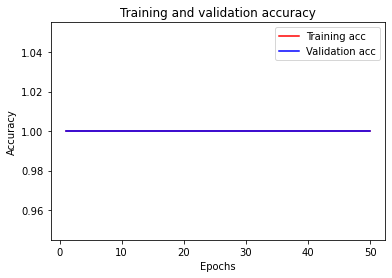

In [57]:
plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [64]:
results = model.evaluate(X_train, y_train)
results

35/35 [==============================] - 0s 2ms/step - loss: 0.2216 - accuracy: 1.0000


[0.22164063155651093, 1.0]

In [59]:
predictions = model.predict(X_test)

5/5 [==============================] - 0s 2ms/step


MSE = 1.6286083


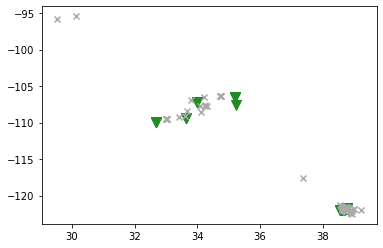

In [60]:
y_test_split = np.hsplit(y_test, 2)
pred_test = np.hsplit(predictions, 2)

plt.scatter(y_test_split[0], y_test_split[1], marker='v', s=100, color='forestgreen')
plt.scatter(pred_test[0], pred_test[1], color='darkgray', marker='x')

mse = MeanSquaredError()
mse = mse(y_test, predictions).numpy()
print("MSE = " + str(mse))


5/5 [==============================] - 0s 4ms/step
MSE = 0.49991432


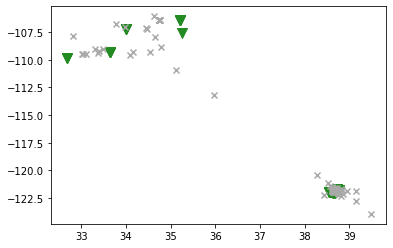

In [61]:
validate_predictions = model.predict(X_val)

y_val_split = np.hsplit(y_val, 2)
val_pred_test = np.hsplit(validate_predictions, 2)

plt.scatter(y_val_split[0], y_val_split[1], marker='v', s=100, color='forestgreen')
plt.scatter(val_pred_test[0], val_pred_test[1], color='darkgray', marker='x')

mse = MeanSquaredError()
mse = mse(y_val, validate_predictions).numpy()
print("MSE = " + str(mse))

In [62]:
X_train.shape

(1105, 182)